In [1]:
import json
import random

import pandas as pd
import numpy as np

import networkx as nx
from scipy.sparse.csgraph import floyd_warshall
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from ware_ops_algos.algorithms.visualization import plot_route_with_directions
from ware_ops_algos.algorithms import GreedyItemAssignment, BatchObject, DueDateBatching
from ware_ops_algos.domain_models import (
    StorageLocation, StorageSlot, StorageLocations, StorageType, Location,
    LayoutNetwork, LayoutParameters, LayoutData, LayoutType, ResolvedOrderPosition, PickCart, DimensionType
)

In [2]:
LANE_OFFSET = 1925  # half-gap between the two one-way lanes (mm); set to ~rack depth

In [10]:
from ware_ops_algos.algorithms import RoutingSolution, HeuristicRouting, Route, PickPosition

class LadderRouting(HeuristicRouting):
    """
    Routing for a two-lane ladder aisle graph.

    Each aisle has a left lane (up) and a right lane (down). The picker:
      1. enters the left lane at the bottom cross-aisle
      2. walks upward, collecting all left-face picks in ascending y order
      3. crosses to the right lane at the highest needed level
      4. walks downward, collecting all right-face picks in descending y order
      5. exits at the bottom cross-aisle and moves to the next aisle

    If an aisle has picks on only one face the picker uses return routing on
    that lane (walk up to the deepest pick, return to the bottom).

    Aisles are visited in ascending x order (nearest-first). The start/end
    depot is the centerline bottom of the first aisle.
    """
    algo_name = "LadderRouting"

    def __init__(
        self,
        start_node,
        end_node,
        closest_node_to_start,
        min_aisle_position,
        max_aisle_position,
        distance_matrix,
        predecessor_matrix,
        picker,
        aisle_x: dict,
        lane_offset: int = LANE_OFFSET,
        fixed_depot: bool = True,
        **kwargs,
    ):
        super().__init__(
            start_node=start_node,
            end_node=end_node,
            closest_node_to_start=closest_node_to_start,
            min_aisle_position=min_aisle_position,
            max_aisle_position=max_aisle_position,
            distance_matrix=distance_matrix,
            predecessor_matrix=predecessor_matrix,
            picker=picker,
            fixed_depot=fixed_depot,
            **kwargs,
        )
        self.lane_offset = lane_offset
        self._lane_to_center: dict[float, float] = {}
        for center in aisle_x.values():
            self._lane_to_center[center - lane_offset] = center
            self._lane_to_center[center + lane_offset] = center
        self._center_xs = sorted(set(aisle_x.values()))

    # ── helpers ───────────────────────────────────────────────────────────────

    def _aisle_x_from_pick_node(self, pick_node) -> float:
        x = pick_node[0]
        if x in self._lane_to_center:
            return self._lane_to_center[x]
        return min(self._center_xs, key=lambda cx: abs(cx - x))

    def _left_node(self, center_x, y) -> tuple:
        return (center_x - self.lane_offset, y)

    def _right_node(self, center_x, y) -> tuple:
        return (center_x + self.lane_offset, y)

    def _center_node(self, center_x, y) -> tuple:
        return (center_x, y)

    def _split_by_lane(self, picks: list) -> tuple[list, list]:
        """Split pick positions into left-lane and right-lane by their x offset."""
        left, right = [], []
        for p in picks:
            x = p.pick_node[0]
            center = self._aisle_x_from_pick_node(p.pick_node)
            (left if x < center else right).append(p)
        return left, right

    def _walk(self, source, target, is_pick=False, is_end=False) -> tuple:
        return self._walk_to_target(source, target,
                                    target_is_pick_node=is_pick,
                                    target_is_end_node=is_end)

    def _process_aisle_ladder(
        self,
        current_source: tuple,
        center_x: float,
        aisle_picks: list,
        entry_y: float,
        exit_y: float,
    ) -> tuple:
        """
        Always complete the full loop: up left lane, cross at top, down right lane.
        Picks on whichever face are collected in passing.
        """
        x_left  = center_x - self.lane_offset
        x_right = center_x + self.lane_offset

        # determine the deepest pick on either face to know where to turn
        left_picks  = sorted([p for p in aisle_picks if p.pick_node[0] < center_x],
                             key=lambda p: p.pick_node[1])
        right_picks = sorted([p for p in aisle_picks if p.pick_node[0] >= center_x],
                             key=lambda p: p.pick_node[1], reverse=True)

        # turn point: deepest pick on either face, or the top cross-aisle if none
        top_y = max(
            (p.pick_node[1] for p in aisle_picks),
            default=entry_y,
        )

        center_entry = (center_x, entry_y)
        left_entry   = (x_left,  entry_y)
        right_entry  = (x_right, entry_y)
        left_top     = (x_left,  top_y)
        right_top    = (x_right, top_y)

        # move to centerline then enter left lane at bottom
        current_source = self._walk(current_source, center_entry)
        current_source = self._walk(current_source, left_entry)

        # walk up left lane, picking left-face items in ascending order
        for p in left_picks:
            current_source = self._walk(current_source, p.pick_node, is_pick=True)

        # walk to turn point on left lane
        current_source = self._walk(current_source, left_top)

        # cross to right lane at turn point
        current_source = self._walk(current_source, right_top)

        # walk down right lane, picking right-face items in descending order
        for p in right_picks:
            if p.pick_node[1] <= top_y:
                current_source = self._walk(current_source, p.pick_node, is_pick=True)

        # exit to bottom right, then back to centerline
        current_source = self._walk(current_source, right_entry)
        current_source = self._walk(current_source, center_entry)

        return current_source

    def _run(self, pick_list: list[PickPosition]) -> RoutingSolution:
        self.reset_parameters()
        self.pick_list = list(pick_list)
        self.current_order = list(pick_list)

        picks_by_aisle: dict[float, list] = defaultdict(list)
        for p in pick_list:
            cx = self._aisle_x_from_pick_node(p.pick_node)
            picks_by_aisle[cx].append(p)

        aisle_order = sorted(picks_by_aisle.keys())

        entry_y = self.closest_node_to_start[1]
        exit_y  = entry_y

        current_source = self._walk(self.start_node, self.closest_node_to_start)

        for center_x in aisle_order:
            current_source = self._process_aisle_ladder(
                current_source, center_x, picks_by_aisle[center_x],
                entry_y, exit_y,
            )

        self._go_to_end_node(current_source)

        return RoutingSolution(
            algo_name=self.algo_name,
            route=Route(
                route=self.route,
                item_sequence=self.item_sequence,
                distance=self.distance,
                annotated_route=self.annotated_route,
            ),
        )

In [11]:
def visualize_tour(G, route: list, pick_nodes: set, aisle_x, cross_aisle_y,
                   lane_offset=LANE_OFFSET, figsize=(14, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    # ── background graph ────────────────────────────────────────────────────
    for u, v, d in G.edges(data=True):
        et = d.get("edge_type", "")
        if et == "lane":
            color, lw, ls, zorder = "#cccccc", 0.8, "-", 1
        elif et == "cross":
            color, lw, ls, zorder = "#aaaaff", 1.2, "--", 2
        elif et == "cross_aisle":
            color, lw, ls, zorder = "#888888", 1.0, "-", 1
        elif et == "connector":
            color, lw, ls, zorder = "#dddddd", 0.6, ":", 1
        else:
            continue
        ax.plot([u[0], v[0]], [u[1], v[1]], color=color, lw=lw,
                linestyle=ls, zorder=zorder)

    # ── aisle labels ────────────────────────────────────────────────────────
    y_mid = (min(cross_aisle_y) + max(cross_aisle_y)) / 2
    for i, cx in enumerate(sorted(aisle_x.values())):
        ax.text(cx, y_mid, f"A{i+1}", ha="center", va="center",
                fontsize=7, color="#999999", zorder=3)

    # ── pick nodes ──────────────────────────────────────────────────────────
    for n in G.nodes():
        if not isinstance(n, tuple) or len(n) != 2:
            continue
        if G.nodes[n].get("node_type") == "pick_node":
            color = "red" if n in pick_nodes else "#dddddd"
            size  = 40   if n in pick_nodes else 8
            ax.scatter(*n, s=size, color=color, zorder=5)

    # ── tour path with arrows ───────────────────────────────────────────────
    if route and len(route) >= 2:
        xs = [n[0] for n in route if isinstance(n, tuple)]
        ys = [n[1] for n in route if isinstance(n, tuple)]
        ax.plot(xs, ys, color="red", lw=1.5, zorder=6, alpha=0.8)

        # draw arrows every N steps to show direction
        step = max(1, len(xs) // 30)
        for i in range(0, len(xs) - 1, step):
            dx, dy = xs[i+1] - xs[i], ys[i+1] - ys[i]
            if abs(dx) + abs(dy) < 1:
                continue
            ax.annotate("", xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                        arrowprops=dict(arrowstyle="->", color="darkred",
                                        lw=1.0), zorder=7)

    # ── start / end markers ─────────────────────────────────────────────────
    if route:
        start = next((n for n in route if isinstance(n, tuple)), None)
        end   = next((n for n in reversed(route) if isinstance(n, tuple)), None)
        if start: ax.scatter(*start, s=120, color="green",  zorder=8, marker="*", label="start")
        if end:   ax.scatter(*end,   s=120, color="purple", zorder=8, marker="X", label="end")

    # ── legend ──────────────────────────────────────────────────────────────
    legend = [
        mpatches.Patch(color="#cccccc", label="lane"),
        mpatches.Patch(color="#aaaaff", label="cross (rung)"),
        mpatches.Patch(color="#888888", label="cross-aisle"),
        mpatches.Patch(color="red",     label="pick node (in tour)"),
        mpatches.Patch(color="green",   label="start"),
        mpatches.Patch(color="purple",  label="end"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=7)
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title("Picker tour")
    plt.tight_layout()
    plt.show()


def get_processing_time(solution, picker_speed_mm_s, time_per_pick_s, picks):
    route = [n for n in solution.route.route if isinstance(n, tuple)]
    total_dist_mm = 0.0
    missing = []
    total_dist_mm = solution.route.distance

    n_picks = len(picks)
    travel_time_s  = total_dist_mm / picker_speed_mm_s
    pick_time_s    = n_picks * time_per_pick_s
    total_time_s   = travel_time_s + pick_time_s
    total_time_min = total_time_s / 60
    return {
        "total_dist_mm": total_dist_mm,
        "travel_time_s": travel_time_s,
        "pick_time_s":   pick_time_s,
        "total_time_s":  total_time_s,
    }

def validate_tour_distances(solution, picker_speed_mm_s: float,
                            time_per_pick_s: float, layout_network,
                            picks: list):
    """
    Compare tour distance / time against observed pick times.

    picker_speed_mm_s : e.g. 1306 (mm/s)
    time_per_pick_s   : e.g. 19   (s)
    """
    dm = layout_network.distance_matrix
    route = [n for n in solution.route.route if isinstance(n, tuple)]
    pick_nodes_set = {p.pick_node for p in picks}

    # ── recompute distance step by step ─────────────────────────────────────
    total_dist_mm = 0.0
    missing = []
    for a, b in zip(route, route[1:]):
        try:
            total_dist_mm += dm.at[a, b]
        except KeyError:
            missing.append((a, b))

    n_picks = len(picks)
    travel_time_s  = total_dist_mm / picker_speed_mm_s
    pick_time_s    = n_picks * time_per_pick_s
    total_time_s   = travel_time_s + pick_time_s
    total_time_min = total_time_s / 60

    # ── single-aisle sanity: one full aisle up+down ─────────────────────────
    aisle_length_mm = max(dm.index, key=lambda n: n[1] if isinstance(n, tuple) else 0)[1]
    aisle_loop_mm   = 2 * aisle_length_mm
    aisle_loop_s    = aisle_loop_mm / picker_speed_mm_s
    aisle_loop_min  = aisle_loop_s / 60

    print(f"Tour distance      : {total_dist_mm/1000:.1f} m")
    print(f"Travel time        : {travel_time_s:.0f} s  ({travel_time_s/60:.1f} min)")
    print(f"Pick time          : {pick_time_s:.0f} s  ({n_picks} picks × {time_per_pick_s}s)")
    print(f"Total time         : {total_time_s:.0f} s  ({total_time_min:.1f} min)")
    print()
    print(f"One full aisle loop: {aisle_loop_mm/1000:.1f} m  "
          f"→ {aisle_loop_s:.0f} s  ({aisle_loop_min:.1f} min)")
    print(f"Expected per aisle : ≈{2*53:.0f} m  →  ≈{2*53000/picker_speed_mm_s:.0f} s")
    if missing:
        print(f"\nWARNING: {len(missing)} step(s) missing from distance matrix: {missing[:3]}")

    return {
        "total_dist_mm": total_dist_mm,
        "travel_time_s": travel_time_s,
        "pick_time_s":   pick_time_s,
        "total_time_s":  total_time_s,
    }

In [12]:
layout_raw = pd.read_csv("../../../scenarios/scenario_ijpe/data/layout.csv", sep=";")
layout_np = layout_raw.to_numpy()

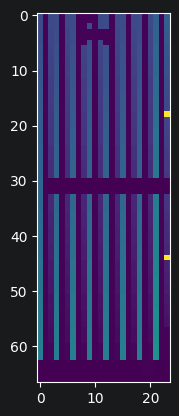

In [13]:
plt.imshow(layout_np)

In [14]:
from pathlib import Path
from omegaconf import OmegaConf
from scenarios.experiment_commons import build_data_loader


cfg = OmegaConf.create({
    # Needed by build_data_loader()
    "instances_base": "data",

    "data_card": {
        # Needed by build_data_loader()
        "name": "grocery_retailer",

        # Used inside WarehousePickingLoader._build_domain()
        "problem_type": "ORSP",

        "source": {
            # Needed by build_data_loader()
            "data_loader": "WarehousePickingLoaderDigraph",

            # Needed when calling loader.load(...)
            "orders_path": "../data/order_stream.csv",
            "layout_path": "../data/layout.csv",
        },
    },
})

loader = build_data_loader(cfg)
domain = loader.load(cfg.data_card.source.orders_path, cfg.data_card.source.layout_path)

In [15]:
ia = GreedyItemAssignment(domain.storage)
ia_sol = ia.solve(domain.orders.orders)

In [16]:
layout_network = domain.layout.layout_network
resources = domain.resources

aisle_x = loader._compute_aisle_x(layout_np)
cross_aisle_y = loader._compute_cross_aisle_y(layout_np)

ladder_router = LadderRouting(
            start_node=layout_network.start_node,
            end_node=layout_network.end_node,
            closest_node_to_start=layout_network.closest_node_to_start,
            min_aisle_position=layout_network.min_aisle_position,
            max_aisle_position=layout_network.max_aisle_position,
            distance_matrix=layout_network.distance_matrix,
            predecessor_matrix=layout_network.predecessor_matrix,
            picker=resources.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=layout_network.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(layout_network.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(layout_network.graph.nodes))},
            fixed_depot=True,
            aisle_x=aisle_x,
        )

In [17]:
sum_pt = 0
for o in ia_sol.resolved_orders:
    pl = o.pick_positions
    ladder_sol = ladder_router.solve(pl)
    validation = get_processing_time(ladder_sol, 2306, 19, pl)
    ladder_router.reset_parameters()
    print(validation["total_time_s"])
    sum_pt += validation["total_time_s"]

1501.925411968777
1064.925411968777
1197.925411968777
1064.925411968777
1483.5385949696445
1293.1491760624458
912.0260190806591
529.1699913269731
1216.0260190806591
760.0260190806591
1045.0260190806591
874.0260190806591
1235.0260190806591
1178.0260190806591
1178.0260190806591
798.0260190806591
1672.925411968777
874.0260190806591
1444.0260190806591
184.5368603642671
2356.925411968777
173.7823070251518
1653.925411968777
2071.925411968777
836.0260190806591
1479.028620988725
1805.0260190806591
874.0260190806591
108.72246313963574
1501.925411968777
1576.8846487424112
760.0260190806591
1482.0260190806591
1523.2237640936687
1102.0260190806591
1178.0260190806591
1121.0260190806591
1368.0260190806591
1254.0260190806591
1064.0260190806591
2850.925411968777
1900.925411968777
1340.8629661751952
1102.0260190806591
1976.925411968777
944.6001734605377
1045.0260190806591
2318.925411968777
948.0693842150911
1615.925411968777
1208.9462272333044
1029.6201214223765
964.5602775368604
1200.24197745013
1539.

In [18]:
sum_pt

np.float64(1314576.8490893464)

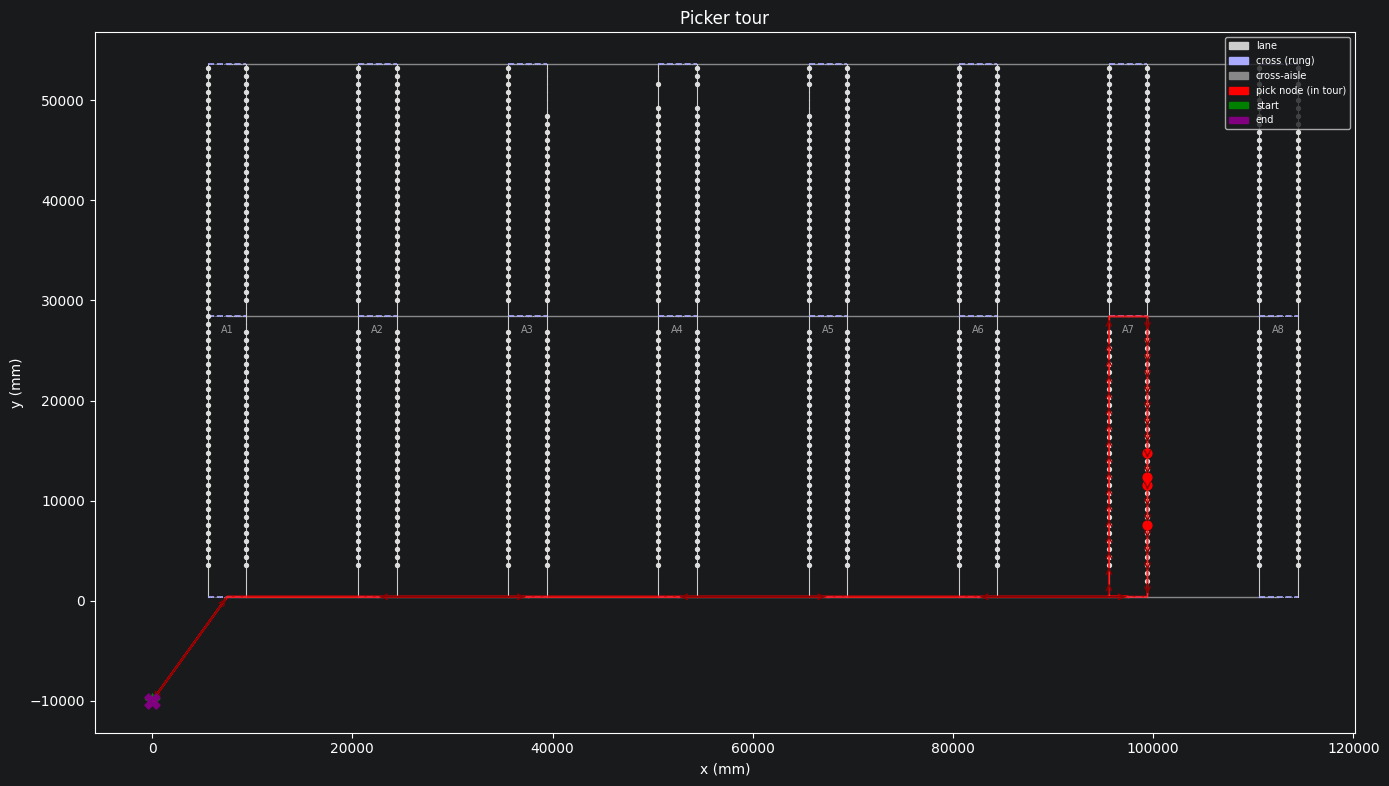

Tour distance      : 243.7 m
Travel time        : 106 s  (1.8 min)
Pick time          : 76 s  (4 picks × 19s)
Total time         : 182 s  (3.0 min)

One full aisle loop: 107.2 m  → 46 s  (0.8 min)
Expected per aisle : ≈106 m  →  ≈46 s


{'total_dist_mm': np.float64(243700.0),
 'travel_time_s': np.float64(105.68083261058109),
 'pick_time_s': 76,
 'total_time_s': np.float64(181.6808326105811)}

In [19]:
pick_nodes_in_tour = {p.pick_node for p in pl}
visualize_tour(domain.layout.layout_network.graph, ladder_sol.route.route, pick_nodes_in_tour,
               aisle_x, cross_aisle_y)

validate_tour_distances(ladder_sol, picker_speed_mm_s=2306,
                        time_per_pick_s=19,
                        layout_network=domain.layout.layout_network,
                        picks=pl)

In [20]:
cfg = OmegaConf.create({
    "instances_base": "data",

    "data_card": {
        "name": "grocery_retailer",
        "problem_type": "ORSP",
        "source": {
            "data_loader": "WarehousePickingLoader",
            "orders_path": "../data/order_stream.csv",
            "layout_path": "../data/layout.csv",
        },
    },
})

loader = build_data_loader(cfg)
domain = loader.load(cfg.data_card.source.orders_path, cfg.data_card.source.layout_path, use_cache=False)

Loader
pre jobs


In [21]:
from casim.io_helpers import load_json

order_id_map = load_json("../data/id_maps.json")

In [22]:
order_pt = {}
for j in loader.jobs:
    order_pt[j.job.batch.orders[0].order_id] = j.job.processing_time

In [23]:
ia = GreedyItemAssignment(domain.storage)
ia_sol = ia.solve(domain.orders.orders)

In [30]:
from ware_ops_algos.algorithms import PickListRouting, SShapeRouting, NearestNeighbourhoodRouting, ReturnRouting

ln = domain.layout.layout_network
res = domain.resources

ret_router = ReturnRouting(
            start_node=ln.start_node,
            end_node=ln.end_node,
            closest_node_to_start=ln.closest_node_to_start,
            min_aisle_position=ln.min_aisle_position,
            max_aisle_position=ln.max_aisle_position,
            distance_matrix=ln.distance_matrix,
            predecessor_matrix=ln.predecessor_matrix,
            picker=res.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=ln.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(ln.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(ln.graph.nodes))},
            fixed_depot=True
        )



In [69]:
sum_pt = 0
for o in ia_sol.resolved_orders:
    pl = o.pick_positions
    ret_sol = ret_router.solve(pl)
    validation = get_processing_time(ret_sol, 2306, 25.7, pl)
    ret_router.reset_parameters()
    print(validation["total_time_s"])
    sum_pt += validation["total_time_s"]


1829.424111014744
1228.6103209019948
1425.8563746747614
1216.1211621856028
1855.7901127493496
1472.6628794449261
1148.4993928881179
638.6902862098873
1565.2501300954032
947.0624457935819
1331.8686036426714
1097.0993928881178
1590.2562879444927
1513.1562879444925
1513.850130095403
997.7686036426712
2074.6009540329574
1099.8747614917606
1873.6501300954033
198.8692974848222
3022.003902862099
184.99245446660882
2053.757849089332
2624.014744145707
1049.1686036426713
1861.3408499566349
2361.9501300954034
1101.9562879444925
107.92029488291413
1859.2593235039028
1934.9994796183869
940.8178664353859
1924.3562879444926
1949.486643538595
1410.3562879444926
1512.4624457935818
1433.9747614917605
1770.850130095403
1611.099392888118
1358.9562879444927
3684.653165654813
2405.203902862099
1566.387250650477
1404.1117085862966
2496.902428447528
1099.416478751084
1329.7870771899393
2961.5839549002603
1077.2135299219426
1997.5009540329575
1451.5563746747616
1209.1549002601907
1180.6516912402428
1472.080398

In [67]:
sum_pt

np.float64(1648724.3776235944)

In [68]:
sum(order_pt.values()) - sum_pt

np.float64(-5172.377623594366)

In [71]:
sum(order_pt.values())

1643552.0

In [65]:
(sum(order_pt.values()) - sum_pt) / 3600

np.float64(0.060478437890867806)

In [35]:
sum(order_pt.values()) - 1470373

173179.0

In [36]:
173179 / 3600

48.10527777777778

In [ ]:
validate_tour_distances(ret_sol, picker_speed_mm_s=2306,
                        time_per_pick_s=19,
                        layout_network=domain.layout.layout_network,
                        picks=pl)

In [ ]:
# df = pd.read_excel("./orders.xlsx", sheet_name="Clean OP Data", dtype={"PALNR": str})
# df["ARTIKELNR"] = df["ARTIKELNR"].astype(str).str[:-4]


In [ ]:
df = pd.read_excel(
    "./OrdPick_REWE051_2026_04_13.xlsx",
    sheet_name="Tabelle1",
    dtype={
        "PALNR": str,
        "ARTIKELNR": str,
    }
)

df["ARTIKELNR"] = (
    df["ARTIKELNR"]
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)
if not "picklocation" in df.columns:
    df['picklocation'] = df['House'] * 100 + df['Lagerplatz House']
df["date"] = pd.to_datetime(df["NEU_DATUM"], format="%d.%m.%Y").dt.date
df["loc"] = df["Gang"].astype(str) + "_" + df["House"].astype(str) + "_" + df["picklocation"].astype(str)
df["t_sec"] = pd.to_timedelta(df["BEGINN_ZEIT"].astype(str)).dt.total_seconds()
df.rename(columns={"Gang": "aisle", "House": "house"}, inplace=True)
df = df[df["aisle"].isin([1,2,3,4,5,6,7,8])]
df = df[df["ARTIKELNR"] != "78612860004"]

In [ ]:
df_master_data = pd.read_excel(
    "./LBH_REWE051_2026_04_13.xlsx",
    dtype={"ARTIKELNR": str}
)

df_master_data.columns = (
    df_master_data.columns
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
)

df_master_data["ARTIKELNR"] = (
    df_master_data["ARTIKELNR"]
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

In [ ]:
# df_master_data["ARTIKELNR"] = df_master_data["ARTIKELNR"].astype(str)

In [ ]:
df.columns

In [ ]:
df.ARTIKELNR.nunique()

In [ ]:
df_master_data.ARTIKELNR.nunique()

In [ ]:
df = df.merge(right=df_master_data[["ARTIKELNR", "Länge", "Höhe", "Breite"]], on="ARTIKELNR")

In [ ]:
df["UNIT_WEIGHT"] = df["GEWICHT_SOLL"] / df["MENGE_IST"]

In [ ]:
df = df[df["NEU_DATUM"].notna()]

In [ ]:
n_tours = df["AUFTRAGSNR"].nunique()
print(n_tours)

In [ ]:
n_locs = df["loc"].nunique()
print(n_locs)

In [ ]:
df.groupby(by="date")["AUFTRAGSNR"].nunique()

In [ ]:
len(list(df["ARTIKELNR"].unique()))

In [ ]:
df.groupby("ARTIKELNR")[["aisle", "house", "picklocation"]].nunique().describe()

In [ ]:
rows_per_line = df.groupby(["AUFTRAGSNR", "ARTIKELNR"]).size()
print(rows_per_line.describe())
print("Lines with >1 row:", (rows_per_line > 1).sum(), "/", len(rows_per_line))

In [ ]:
df.columns

In [ ]:
CCG1_WIDTH = 800
CCG1_LENGTH = 1200
WIDTH_AISLE_SEGMENT = 800
LENGTH_AISLE_SEGMENT = 12600
AISLE_KEYS = {-1, -2, -3, -4, -5, -6, -7, -8}
RB_RANGES = [range(2210, 2284), range(2310, 2384), range(2010, 2084)]


def cell_kind(val):
    if val in AISLE_KEYS: return "aisle"
    if val == -90:        return "cross_aisle"
    if val == -99:        return "special_pick"
    if val > 0:           return "pick"
    return "transit"


def compute_aisle_x(layout_np):
    aisle_x = {}
    offset_h = 0
    max_y = 0
    mid_row = layout_np.shape[0] // 2
    for col in range(layout_np.shape[1]):
        offset_h += max_y
        val = layout_np[mid_row, col]
        kind = cell_kind(val)
        if kind == "aisle":
            aisle_x[val] = offset_h + LENGTH_AISLE_SEGMENT / 2
            max_y = LENGTH_AISLE_SEGMENT
        elif kind in ("pick", "special_pick"):
            max_y = CCG1_LENGTH
        else:
            max_y = LENGTH_AISLE_SEGMENT
    return aisle_x


def compute_cross_aisle_y(layout_np):
    cross_y = []
    offset_v = 0
    in_cross = False
    cross_start = 0

    for row in reversed(range(layout_np.shape[0])):
        row_vals = layout_np[row, :]
        is_cross_row = all(v == -90 for v in row_vals)

        if is_cross_row:
            if not in_cross:
                cross_start = offset_v
                in_cross = True
            offset_v += WIDTH_AISLE_SEGMENT
        else:
            if in_cross:
                cross_y.append((cross_start + offset_v) / 2)
                in_cross = False
            first_val = next((v for v in row_vals if v != -90), None)
            if first_val is not None and (first_val > 0 or first_val == -99):
                offset_v += CCG1_WIDTH
            else:
                offset_v += WIDTH_AISLE_SEGMENT

    if in_cross:
        cross_y.append((cross_start + offset_v) / 2)

    cross_y.append(offset_v)
    cross_y.append(28400)  # warehouse-specific endpoint, see note below
    return sorted(set(cross_y))


def adjacent_aisle(layout_np, row, col):
    candidates = []
    if col > 0:                          candidates.append(layout_np[row, col - 1])
    if col < layout_np.shape[1] - 1:     candidates.append(layout_np[row, col + 1])
    if row > 0:                          candidates.append(layout_np[row - 1, col])
    if row < layout_np.shape[0] - 1:     candidates.append(layout_np[row + 1, col])
    return next((c for c in candidates if c in AISLE_KEYS), None)

LANE_OFFSET = 1925  # half-gap between the two one-way lanes (mm); set to ~rack depth


def adjacent_aisle_and_lane(layout_np, row, col):
    """Aisle id plus the lane the bay's face feeds.

    Convention: aisle to the RIGHT of the bay -> bay on the aisle's left face
    -> up lane. Aisle to the LEFT -> down lane. Flip the two lane labels if
    your pickers ascend on the other side.
    """
    if col < layout_np.shape[1] - 1 and layout_np[row, col + 1] in AISLE_KEYS:
        return layout_np[row, col + 1], "up"
    if col > 0 and layout_np[row, col - 1] in AISLE_KEYS:
        return layout_np[row, col - 1], "down"
    if row > 0 and layout_np[row - 1, col] in AISLE_KEYS:
        return layout_np[row - 1, col], "up"
    if row < layout_np.shape[0] - 1 and layout_np[row + 1, col] in AISLE_KEYS:
        return layout_np[row + 1, col], "down"
    return None, None

def house_from_val(val):
    s = str(int(val))
    if len(s) == 4: return s[:2]
    if len(s) == 3: return s[:1]
    return "0"


def slots_for(val):
    val = int(val)
    for rng in RB_RANGES:
        if val in rng:
            return [StorageSlot(id=str(rb_id), level=0) for rb_id in rng]
    return [
        StorageSlot(id=str(val), level=0),
        StorageSlot(id=str(val + 1), level=1),
    ]


def build_storage_locations(layout_np, aisle_x):
    locations = []
    offset_h = 0
    max_y = 0

    for col in range(layout_np.shape[1]):
        offset_v = 0
        offset_h += max_y
        for row in reversed(range(layout_np.shape[0])):
            val = layout_np[row, col]
            kind = cell_kind(val)

            if kind == "pick":
                a_id, lane = adjacent_aisle_and_lane(layout_np, row, col)
                house = house_from_val(val)
                aisle_str = str(-a_id) if a_id else "0"
                y_center = offset_v + CCG1_WIDTH / 2

                pick_node = None
                if a_id in aisle_x:
                    x = aisle_x[a_id]
                    lane_x = x - LANE_OFFSET if lane == "up" else x + LANE_OFFSET
                    pick_node = (lane_x, y_center)

                loc = StorageLocation(
                    id=f"{aisle_str}_{house}",
                    aisle_id=a_id,
                    slots=slots_for(val),
                    bbox=None,
                )
                loc.pick_node = pick_node
                loc.lane = lane
                locations.append(loc)
                max_y = CCG1_LENGTH
                offset_v += CCG1_WIDTH
            elif kind == "special_pick":
                max_y = CCG1_LENGTH
                offset_v += CCG1_WIDTH
            elif kind == "aisle":
                max_y = LENGTH_AISLE_SEGMENT
                offset_v += LENGTH_AISLE_SEGMENT
            else:
                max_y = LENGTH_AISLE_SEGMENT
                offset_v += WIDTH_AISLE_SEGMENT

    return locations


def build_graph(aisle_x, cross_aisle_y, storage_locations):
    G = nx.Graph()
    cross_y = sorted(cross_aisle_y)

    # centerline cross-aisle nodes + horizontal edges between aisles
    for a_id, x in aisle_x.items():
        for y in cross_y:
            G.add_node((x, y), pos=(x, y), node_type="intersection", aisle_id=a_id)
    x_sorted = sorted(aisle_x.values())
    for y in cross_y:
        for x1, x2 in zip(x_sorted, x_sorted[1:]):
            G.add_edge((x1, y), (x2, y), weight=x2 - x1, edge_type="cross_aisle")

    # picks grouped by aisle and face
    face_picks: dict[tuple, list] = defaultdict(list)
    for loc in storage_locations:
        if loc.pick_node is None:
            continue
        x = aisle_x[loc.aisle_id]
        G.add_node(loc.pick_node, pos=loc.pick_node, node_type="pick_node",
                   slot_id=loc.id, aisle_id=loc.aisle_id, lane=loc.lane)
        face_picks[(x, loc.lane)].append(loc.pick_node)

    for x in aisle_x.values():
        x_left, x_right = x - LANE_OFFSET, x + LANE_OFFSET

        # every level the picker can be at: cross-aisles + all picks on both faces
        ys = sorted(set(cross_y)
                    | {p[1] for p in face_picks[(x, "up")]}
                    | {p[1] for p in face_picks[(x, "down")]})

        # vertical run on each side
        for lane_x in (x_left, x_right):
            chain = [(lane_x, y) for y in ys]
            for n1, n2 in zip(chain, chain[1:]):
                G.add_edge(n1, n2, weight=n2[1] - n1[1], edge_type="lane")

        # rungs: cross left<->right at any level, cost = aisle width
        # for y in ys:
        #     G.add_edge((x_left, y), (x_right, y), weight=2 * LANE_OFFSET, edge_type="cross")
        for y in cross_y:  # not ys
            G.add_edge((x_left, y), (x_right, y),
                       weight=2 * LANE_OFFSET, edge_type="cross")
        # tie lanes to the centerline at cross-aisles for inter-aisle travel
        for y in cross_y:
            G.add_edge((x, y), (x_left, y), weight=LANE_OFFSET, edge_type="connector")
            G.add_edge((x, y), (x_right, y), weight=LANE_OFFSET, edge_type="connector")

    for n in G.nodes():
        G.nodes[n].setdefault("pos", n)
    return G

def build_layout_data(layout_np, storage_locations, allow_through=True):
    aisle_x = compute_aisle_x(layout_np)
    cross_aisle_y = compute_cross_aisle_y(layout_np)
    G = build_graph(aisle_x, cross_aisle_y, storage_locations)

    start_location = (0, -10000)
    end_location = (-1, -10000)
    first_intersection = (sorted(aisle_x.values())[0], cross_aisle_y[0])
    G.add_node(start_location, pos=start_location, node_type="start_node")
    G.add_node(end_location, pos=end_location, node_type="end_node")
    G.add_edge(start_location, first_intersection, weight=0)   # enter
    G.add_edge(first_intersection, end_location, weight=0)     # exit (was undirected)

    nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", dtype=float)
    dist_raw, predecessors = floyd_warshall(A, directed=True, return_predecessors=True)
    dist_matrix = pd.DataFrame(dist_raw, index=nodes, columns=nodes)

    layout_network = LayoutNetwork(
        graph=G,
        distance_matrix=dist_matrix,
        predecessor_matrix=predecessors,
        closest_node_to_start=(7500, 400),
        min_aisle_position=400,
        max_aisle_position=53600,
        start_node=start_location,
        end_node=end_location,
        node_list=nodes,
    )

    layout_params = LayoutParameters(
        n_aisles=len(aisle_x),
        n_pick_locations=sum(1 for l in storage_locations if l.pick_node is not None),
        n_blocks=2,
        dist_pick_locations=0.8,
        dist_aisle=15,
        dist_top_to_pick_location=0,
        dist_bottom_to_pick_location=0,
        dist_start=0,
        dist_end=0,
        dist_cross_aisle=2.4,
        start_location=start_location,
        end_location=end_location,
        start_connection_point=(0, 0),
        end_connection_point=(0, 0),
    )

    return LayoutData(
        tpe=LayoutType.CONVENTIONAL,
        graph_data=layout_params,
        layout_network=layout_network,
    )

In [ ]:
from ware_ops_algos.domain_models import Articles, Article, ArticleType


def build_articles(orders: pd.DataFrame) -> Articles:
    article_list = []
    seen: set = set()
    for row in orders[["ARTIKELNR", "MENGE_IST", "GEWICHT_SOLL", "VOLUMEN_KOLLI", "Länge", "Höhe", "Breite"]].itertuples(index=False):
        if row.ARTIKELNR not in seen:
            article_list.append(
                Article(
                    article_id=row.ARTIKELNR,
                    weight=row.GEWICHT_SOLL / row.MENGE_IST if row.MENGE_IST else 0.0,  # unit weight
                    volume=row.VOLUMEN_KOLLI,  # TODO Unit volume?
                    length=row.Länge, # Kolli
                    width=row.Breite, # Kolli
                    height=row.Höhe   # Kolli
                )
            )
            seen.add(row.ARTIKELNR)
    return Articles(tpe=ArticleType.STANDARD, articles=article_list)

In [ ]:
articles_domain = build_articles(df)

In [ ]:
aisle_x = compute_aisle_x(layout_np)
cross_aisle_y = compute_cross_aisle_y(layout_np)

storage_locations = build_storage_locations(layout_np, aisle_x)
layout_data = build_layout_data(layout_np, storage_locations)
G = build_graph(aisle_x, cross_aisle_y, storage_locations)

In [ ]:
# where is each article stored | id -> aisle, house, picklocation (house | top / bottom)
storage_master = (
    df.groupby("ARTIKELNR")
      .agg(aisle=("aisle", "first"),
           house=("house", "first"),
           picklocation=("picklocation", "first"))
      .reset_index()
)

# Physical access points to storage
slot_index = {
    (loc.id, slot.id): loc
    for loc in storage_locations
    for slot in loc.slots
}

INFINITE_INVENTORY = 9999
locations: list[Location] = []
unmatched = []

for r in storage_master.itertuples(index=False):
    article_id = str(r.ARTIKELNR)
    loc_key = f"{int(r.aisle)}_{int(r.house)}"
    slot_id = str(int(r.picklocation))

    loc = slot_index.get((loc_key, slot_id))
    if loc is None or loc.pick_node is None:
        unmatched.append((article_id, loc_key, slot_id))
        continue

    locations.append(Location(
        x=loc.pick_node[0],
        y=loc.pick_node[1],
        article_id=article_id,
        amount=INFINITE_INVENTORY,
    ))

storage = StorageLocations(
    tpe=StorageType.DEDICATED,
    locations=locations,
    storage_slots=storage_locations,
)
storage.build_article_location_mapping()

In [ ]:
def check_layout_graph(G, aisle_x, cross_aisle_y, lane_offset=LANE_OFFSET):
    dm = None  # compute lazily if needed
    errors = []

    # 1. basic counts
    n_aisles = len(aisle_x)
    n_segments = len(cross_aisle_y) - 1
    lane_edges = [d for *_, d in G.edges(data=True) if d.get("edge_type") == "lane"]
    cross_edges = [d for *_, d in G.edges(data=True) if d.get("edge_type") == "cross"]
    conn_edges  = [d for *_, d in G.edges(data=True) if d.get("edge_type") == "connector"]
    ca_edges    = [d for *_, d in G.edges(data=True) if d.get("edge_type") == "cross_aisle"]
    print(f"aisles={n_aisles}  segments={n_segments}")
    print(f"lane={len(lane_edges)}  cross={len(cross_edges)}  "
          f"connector={len(conn_edges)}  cross_aisle={len(ca_edges)}")

    # 2. aisle length ≈ 50 m  (y-span between outermost cross-aisle nodes)
    y_lo, y_hi = min(cross_aisle_y), max(cross_aisle_y)
    aisle_length_m = (y_hi - y_lo) / 1000
    print(f"aisle y-span: {aisle_length_m:.1f} m  (expect ≈50)")
    if not (45 < aisle_length_m < 60):
        errors.append(f"aisle length {aisle_length_m:.1f} m outside expected range")

    # 3. aisle width ≈ 3.85 m  (distance between the two lane x-values)
    xs = sorted(aisle_x.values())
    for x in xs:
        x_left, x_right = x - lane_offset, x + lane_offset
        width_m = 2 * lane_offset / 1000
        if abs(width_m - 3.85) > 0.5:
            errors.append(f"aisle x={x}: lane width {width_m:.2f} m, expected 3.85")
    print(f"lane width: {2*lane_offset/1000:.2f} m  (expect 3.85 → LANE_OFFSET={1925})")

    # 4. inter-aisle spacing ≈ 15 m
    for x1, x2 in zip(xs, xs[1:]):
        gap_m = (x2 - x1) / 1000
        if not (12 < gap_m < 18):
            errors.append(f"inter-aisle gap {x1}→{x2}: {gap_m:.1f} m, expected ≈15")
    gaps = [(x2-x1)/1000 for x1,x2 in zip(xs, xs[1:])]
    print(f"inter-aisle gaps (m): min={min(gaps):.1f} max={max(gaps):.1f}  (expect ≈15)")

    # 5. pick spacing ≈ 0.8 m  (consecutive lane edges)
    lane_weights = sorted(set(round(d["weight"]/1000, 2) for d in lane_edges))
    print(f"lane edge lengths (m): {lane_weights}  (expect 0.8 among them)")
    if 0.8 not in lane_weights and not any(abs(w - 0.8) < 0.05 for w in lane_weights):
        errors.append("no lane edge of ≈0.8 m found")

    # 6. cross edges have correct weight = aisle width
    cross_weights = {round(d["weight"]) for d in cross_edges}
    expected_cross = 2 * lane_offset
    if cross_weights - {expected_cross}:
        errors.append(f"cross edges have unexpected weights: {cross_weights}")
    print(f"cross-edge weights (mm): {cross_weights}  (expect {{{expected_cross}}})")

    # 7. directional: travel up left lane cheaper than reverse via matrix
    nodes = list(G.nodes())
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight="weight", dtype=float)
    from scipy.sparse.csgraph import floyd_warshall
    dist_raw = floyd_warshall(A, directed=False, return_predecessors=False)
    dm = pd.DataFrame(dist_raw, index=nodes, columns=nodes)

    x = xs[0]
    x_left = x - lane_offset
    left_nodes = sorted([n for n in G.nodes() if isinstance(n, tuple)
                         and abs(n[0] - x_left) < 1], key=lambda n: n[1])
    if len(left_nodes) >= 2:
        lo_node, hi_node = left_nodes[0], left_nodes[-1]
        d_up   = dm.at[lo_node, hi_node]
        d_down = dm.at[hi_node, lo_node]
        print(f"up   {lo_node} → {hi_node}: {d_up/1000:.1f} m  (expect ≈{aisle_length_m:.1f})")
        print(f"down {hi_node} → {lo_node}: {d_down/1000:.1f} m  (expect ≈{aisle_length_m:.1f})")
        if abs(d_up - d_down) > 1:
            errors.append("undirected: up/down distances differ — graph may be directed")

    # 8. left-to-right cross at a pick level
    x_right = x + lane_offset
    right_nodes = sorted([n for n in G.nodes() if isinstance(n, tuple)
                          and abs(n[0] - x_right) < 1], key=lambda n: n[1])
    if left_nodes and right_nodes:
        # find a y that exists on both sides
        ys_left  = {round(n[1]) for n in left_nodes}
        ys_right = {round(n[1]) for n in right_nodes}
        shared_y = sorted(ys_left & ys_right)
        if shared_y:
            y = shared_y[len(shared_y)//2]
            ln = next(n for n in left_nodes  if abs(n[1]-y)<1)
            rn = next(n for n in right_nodes if abs(n[1]-y)<1)
            d_lr = dm.at[ln, rn]
            d_rl = dm.at[rn, ln]
            expected_cross_m = 2 * lane_offset / 1000
            print(f"left→right at y={y}: {d_lr/1000:.2f} m  (expect {expected_cross_m:.2f})")
            print(f"right→left at y={y}: {d_rl/1000:.2f} m  (expect {expected_cross_m:.2f})")
            if abs(d_lr - 2*lane_offset) > 50:
                errors.append(f"left→right distance {d_lr} ≠ {2*lane_offset}")

    if errors:
        print("\nFAILED:")
        for e in errors: print(" ", e)
    else:
        print("\nAll checks passed.")
    return dm

In [ ]:
check_layout_graph(layout_data.layout_network.graph, aisle_x, cross_aisle_y)

In [ ]:
layout_network = layout_data.layout_network

In [ ]:
from ware_ops_algos.domain_models import ManualPicker
from ware_ops_algos.domain_models import Resources
from ware_ops_algos.domain_models import ResourceType


def _build_resources() -> Resources:
        n_pickers = 17
        picker_speed = 2306 #2306
        time_per_pick = 19
        tour_setup_time = 215 # 215
        aisle_congestion_rate = 0
        n_manual = n_pickers
        start_location = (0, -10000)

        def _cart() -> PickCart:
            return PickCart(n_dimension=1, n_boxes=1, capacities=[1], dimensions=[DimensionType.ORDERS])

        pickers = [
            ManualPicker(
                tpe=ResourceType.HUMAN, id=i, speed=picker_speed,
                current_location=start_location, pick_cart=_cart(),
                time_per_pick=time_per_pick, tour_setup_time=tour_setup_time,
                aisle_congestion_rate=aisle_congestion_rate,
            )
            for i in range(n_manual)
        ]
        return Resources(ResourceType.HUMAN, pickers)

In [ ]:
resources = _build_resources()

In [ ]:
orders = domain.orders.orders

In [ ]:
order = orders[0]

In [ ]:
ia = GreedyItemAssignment(storage)
ia_sol = ia.solve([order])

In [ ]:
import random
sampled_locations = random.sample(storage.locations, 15)

In [ ]:
from ware_ops_algos.algorithms import PickPosition
pl = []
for loc in sampled_locations:
    pl.append(PickPosition(order_number=1, article_id=loc.article_id, amount=1, pick_node=(loc.x, loc.y), in_store=True))

In [ ]:
from ware_ops_algos.algorithms import PickListRouting, SShapeRouting, NearestNeighbourhoodRouting

pl_router = PickListRouting(
            start_node=layout_network.start_node,
            end_node=layout_network.end_node,
            closest_node_to_start=layout_network.closest_node_to_start,
            min_aisle_position=layout_network.min_aisle_position,
            max_aisle_position=layout_network.max_aisle_position,
            distance_matrix=layout_network.distance_matrix,
            predecessor_matrix=layout_network.predecessor_matrix,
            picker=resources.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=layout_network.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(layout_network.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(layout_network.graph.nodes))},
            fixed_depot=True
        )

pl_sol = pl_router.solve(pl)

In [ ]:
for cx in aisle_x.values():
    assert (cx, 400.0) in G.nodes(), f"missing centerline entry node ({cx}, 400)"

In [ ]:
ladder_router = LadderRouting(
            start_node=layout_network.start_node,
            end_node=layout_network.end_node,
            closest_node_to_start=layout_network.closest_node_to_start,
            min_aisle_position=layout_network.min_aisle_position,
            max_aisle_position=layout_network.max_aisle_position,
            distance_matrix=layout_network.distance_matrix,
            predecessor_matrix=layout_network.predecessor_matrix,
            picker=resources.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=layout_network.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(layout_network.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(layout_network.graph.nodes))},
            fixed_depot=True,
            aisle_x=aisle_x,
        )

ladder_sol = ladder_router.solve(pl)

In [ ]:
plot_route_with_directions(layout_data.layout_network.graph, ladder_sol.route.route)

In [ ]:
for p in pl:
    cx = ladder_router._aisle_x_from_pick_node(p.pick_node)
    print(f"{p.pick_node} -> center_x={cx}")

In [ ]:
for p in pl:
    cx = ladder_router._aisle_x_from_pick_node(p.pick_node)
    side = "left" if p.pick_node[0] < cx else "right"
    print(f"{p.pick_node[0]} -> center={cx} side={side}")

In [ ]:
from ware_ops_algos.algorithms import PickListRouting, SShapeRouting, NearestNeighbourhoodRouting, ReturnRouting

ln = domain.layout.layout_network
res = domain.resources

ret_router = SShapeRouting(
            start_node=ln.start_node,
            end_node=ln.end_node,
            closest_node_to_start=ln.closest_node_to_start,
            min_aisle_position=ln.min_aisle_position,
            max_aisle_position=ln.max_aisle_position,
            distance_matrix=ln.distance_matrix,
            predecessor_matrix=ln.predecessor_matrix,
            picker=res.resources,
            gen_tour=True,
            gen_item_sequence=True,
            node_list=ln.node_list,
            node_to_idx={node: idx for idx, node in enumerate(list(ln.graph.nodes))},
            idx_to_node={idx: node for idx, node in enumerate(list(ln.graph.nodes))},
            fixed_depot=True
        )

ret_sol = ret_router.solve(pl)

In [ ]:
df["ARTIKELNR"] = df["ARTIKELNR"].astype(str) #.str #[:-4]
df["MENGE_IST"] = df["MENGE_IST"].astype(float).round().astype(int)
df["date"] = pd.to_datetime(df["NEU_DATUM"], format="%d.%m.%Y").dt.date

# Order-line granularity (collapse multi-row cases)
lines = (
    df.groupby(["date", "AUFTRAGSNR", "ARTIKELNR"], as_index=False)
      .agg(menge=("MENGE_IST", "sum"))
)

# 1. Order count per shift -> distribution across shifts
orders_per_shift = lines.groupby("date")["AUFTRAGSNR"].nunique()
n_orders_samples = orders_per_shift.tolist()  # one number per observed day

# 2. Order size PMF -> aggregated across shifts (size distribution is per-order, not per-shift)
order_sizes = lines.groupby(["date", "AUFTRAGSNR"]).size()
order_size_pmf = (order_sizes.value_counts(normalize=True)
                              .sort_index()
                              .to_dict())

# 3. Article access PMF -> aggregated across shifts
article_counts = lines["ARTIKELNR"].value_counts()
article_pmf = (article_counts / article_counts.sum()).to_dict()

# 4. Per-article quantity distribution -> aggregated across shifts
article_qty = (lines.groupby("ARTIKELNR")["menge"]
                     .apply(list)
                     .to_dict())

calibration = {
    "n_orders_per_shift_samples": n_orders_samples,
    "n_observed_shifts": len(orders_per_shift),
    "order_size_pmf": {str(k): v for k, v in order_size_pmf.items()},
    "article_pmf": article_pmf,
    "article_quantity_samples": article_qty,
}

In [ ]:
calibration

In [ ]:
n_orders_samples

In [ ]:
# calibration["n_orders_per_shift"]

In [ ]:
def generate_instances(
    cal,
    n_instances: int,
    shift_duration_sec: float = 28800.0,
    seed: int = 42,
):
    # with open(calibration_path) as f:
    #     cal = json.load(f)

    n_orders_samples = np.array(cal["n_orders_per_shift_samples"])

    # Order size PMF -> arrays for sampling
    sizes = np.array([int(k) for k in cal["order_size_pmf"].keys()])
    size_probs = np.array(list(cal["order_size_pmf"].values()))
    size_probs /= size_probs.sum()

    # Article access PMF -> arrays for sampling
    articles = np.array(list(cal["article_pmf"].keys()))
    article_probs = np.array(list(cal["article_pmf"].values()))
    article_probs /= article_probs.sum()

    # Per-article quantity samples
    qty_samples = {a: np.array(v) for a, v in cal["article_quantity_samples"].items()}

    # output_dir.mkdir(parents=True, exist_ok=True)

    for instance_idx in range(n_instances):
        rng = np.random.default_rng(seed + instance_idx)
        n_orders = int(rng.choice(n_orders_samples))
        orders = []
        for order_id in range(1, n_orders + 1):
            # How many lines in this order
            n_lines = int(rng.choice(sizes, p=size_probs))
            n_lines = min(n_lines, len(articles))  # safety cap

            # Which articles (without replacement, weighted)
            chosen = rng.choice(articles, size=n_lines, replace=False, p=article_probs)

            # Quantity per article (sample from that article's empirical distribution)
            positions = []
            for art in chosen:
                amount = int(rng.choice(qty_samples[art]))
                positions.append({"article_id": str(art), "amount": amount})

            orders.append({
                "order_id": str(order_id),
                "due_date": shift_duration_sec,
                "positions": positions,
            })

        instance = {
            "meta": {
                "n_orders": n_orders,
                "shift_duration_sec": shift_duration_sec,
                "seed": seed + instance_idx,
                # "calibration_source": str(calibration_path),
            },
            "orders": orders,
        }

        # with open(output_dir / f"instance_{instance_idx + 1}.json", "w") as f:
        #     json.dump(instance, f, indent=2)

    # print(f"Wrote {n_instances} instances to {output_dir}")
    return instance

# Usage
instances = generate_instances(
    # calibration_path=Path("calibration.json"),
    # output_dir=Path("instances/grocery_synthetic"),
    calibration,
    n_instances=1,
    seed=42,
)

In [ ]:
instances

In [ ]:
from pathlib import Path
from ware_ops_algos.domain_models import OrdersDomain, OrderPosition, Order, OrderType


def build_orders_from_instance(instance: dict) -> OrdersDomain:
    # with open(instance_path) as f:
    #     instance = json.load(f)

    order_list = []
    for o in instance["orders"]:
        positions = [
            OrderPosition(
                order_number=o["order_id"],
                article_id=p["article_id"],
                amount=p["amount"],
            )
            for p in o["positions"]
        ]
        order_list.append(Order(
            order_id=o["order_id"],
            order_date=0,
            due_date=float(o["due_date"]),
            order_positions=positions,
        ))
    return OrdersDomain(tpe=OrderType.STANDARD, orders=order_list)

In [ ]:
orders_domain = build_orders_from_instance(instances)

# new try

In [ ]:
# --- Calibration ---
df["ARTIKELNR"] = df["ARTIKELNR"].astype(str)
df["MENGE_IST"] = df["MENGE_IST"].astype(float).round().astype(int)
df["GEWICHT_SOLL"] = df["GEWICHT_SOLL"].astype(str).str.replace(",", ".").astype(float)
df["date"] = pd.to_datetime(df["NEU_DATUM"], format="%d.%m.%Y").dt.date

# Collapse pick events, then aggregate pallets back to market orders
pick_lines = (
    df.groupby(["date", "KUNDENNR", "AUFTRAGSNR", "ARTIKELNR"], as_index=False)
      .agg(menge=("MENGE_IST", "sum"), weight=("GEWICHT_SOLL", "sum"))
)
market_lines = (
    pick_lines.groupby(["date", "KUNDENNR", "ARTIKELNR"], as_index=False)
              .agg(menge=("menge", "sum"), weight=("weight", "sum"))
)

markets_per_shift = market_lines.groupby("date")["KUNDENNR"].nunique().tolist()
lines_per_order = market_lines.groupby(["date", "KUNDENNR"]).size().tolist()

article_counts = market_lines["ARTIKELNR"].value_counts()
article_pmf = (article_counts / article_counts.sum())
articles = article_pmf.index.to_numpy()
probs = article_pmf.to_numpy()

qty_samples = market_lines.groupby("ARTIKELNR")["menge"].apply(list).to_dict()

print(f"{len(market_lines)} order lines, {len(lines_per_order)} market orders, {len(articles)} articles")

In [ ]:
def generate_shift(seed: int):
    rng = np.random.default_rng(seed)
    n_markets = int(rng.choice(markets_per_shift))

    orders = []
    for m in range(1, n_markets + 1):
        target_lines = int(rng.choice(lines_per_order))

        lines, used = [], set()
        while len(lines) < target_lines:
            art = str(rng.choice(articles, p=probs))
            if art in used:
                continue
            qty = int(rng.choice(qty_samples[art]))
            lines.append({"article_id": art, "amount": qty})
            used.add(art)

        orders.append({
            "order_id": f"M{m:04d}",
            "lines": lines,
        })
    return orders

# Try it
shift = generate_shift(seed=42)
print(f"\n{len(shift)} market orders generated")
print(f"First order: {shift[0]}")

In [ ]:
def to_orders_domain(shift: list[dict], shift_duration_sec: float = 28800.0) -> OrdersDomain:
    order_list = []
    for o in shift:
        positions = [
            OrderPosition(
                order_number=o["order_id"],
                article_id=line["article_id"],
                amount=line["amount"],
            )
            for line in o["lines"]
        ]
        order_list.append(Order(
            order_id=o["order_id"],
            order_date=0,
            due_date=shift_duration_sec,
            order_positions=positions,
        ))
    return OrdersDomain(tpe=OrderType.STANDARD, orders=order_list)

In [ ]:
orders_domain = to_orders_domain(shift)

In [ ]:
sizes = [len(o["lines"]) for o in shift]

print(f"Orders: {len(shift)}")
print(f"Lines:   min={min(sizes)}, mean={sum(sizes)/len(sizes):.1f}, max={max(sizes)}")
print(f"Empty orders: {sum(1 for s in sizes if s == 0)}")

In [ ]:
hist_sizes = market_lines.groupby(["date", "KUNDENNR"]).size()
print(f"Historic sizes:   min={hist_sizes.min()}, mean={hist_sizes.mean():.1f}, max={hist_sizes.max()}")

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[1].hist(sizes, bins=30, alpha=0.5, label="synthetic")
ax[1].hist(hist_sizes, bins=30, alpha=0.5, label="historic")
ax[1].set_xlabel("Lines per order"); ax[1].legend()
plt.show()

In [ ]:
df[df["ARTIKELNR"] == "78612860004"]

In [ ]:
ia = GreedyItemAssignment(storage)

In [ ]:
ia_sol = ia.solve(orders_domain.orders)

In [ ]:
from ware_ops_algos.domain_models import Articles
from ware_ops_algos.algorithms import WarehouseOrder
# def simple_batching(warehouse_orders: WarehouseOrder, weight_bound: int, articles: Articles):

In [ ]:
# Split market orders into pallets that need to be picked
# calculate number of pallets needed for one order with upper bound on weight

In [ ]:
articles

In [ ]:
storage_master

In [ ]:
df.columns

In [ ]:
article_mapping = {}
for art in articles_domain.articles:
    if art.article_id not in article_mapping.keys():
        article_mapping[art.article_id] = art


In [ ]:
market_lines

In [ ]:
df.groupby(by=["date", "KUNDENNR"]).agg({"AUFTRAGSNR":"nunique"})

In [ ]:
df.groupby(by="AUFTRAGSNR").agg({"Product_Volume": "sum"}).max()

In [ ]:
length = 120
width = 80
2397.144 / (length * width)

In [ ]:
df["total_volume_L"] = df["MENGE_IST"] * df["VOLUMEN_KOLLI"]

In [ ]:
PALLET_CAPACITY_L = 1728  # 1.8 m on Euro pallet, in liters

df = df.sort_values(["AUFTRAGSNR", "PERS_NR", "BEGINN_ZEIT"]).reset_index(drop=True)

def assign_pallet(group):
    cum, pallet_idx, out = 0, 0, []
    for v in group["total_volume_L"]:  # values are actually in liters
        if cum + v > PALLET_CAPACITY_L:
            pallet_idx += 1
            cum = 0
        out.append(pallet_idx)
        cum += v
    return pd.Series(out, index=group.index)

df["pallet_synth"] = df.groupby(["AUFTRAGSNR","PERS_NR"], group_keys=False).apply(assign_pallet)
df["pallet_id"] = df["AUFTRAGSNR"].astype(str) + "_" + df["pallet_synth"].astype(str)

df.groupby("AUFTRAGSNR")["pallet_id"].nunique().describe()

In [ ]:
df.groupby("AUFTRAGSNR")["pallet_id"].nunique().describe()

In [ ]:
from dataclasses import dataclass, field
from copy import copy

from ware_ops_algos.domain_models import Article, Articles, Order, OrderPosition


MAX_WEIGHT = 1500.0   # kg
MAX_VOLUME = 1500.0   # liters
MAX_HEIGHT = 1800.0   # mm
PALLET_AREA = 1200 * 800  # mm²


@dataclass
class Pallet:
    weight: float = 0.0
    volume: float = 0.0
    height_below: float = 0.0
    layer_height: float = 0.0
    layer_area_used: float = 0.0

    def can_fit(self, art: Article) -> bool:
        if self.weight + art.weight > MAX_WEIGHT:
            return False
        if self.volume + art.volume > MAX_VOLUME:
            return False
        footprint = art.length * art.width
        if art.height <= self.layer_height and self.layer_area_used + footprint <= PALLET_AREA:
            return True
        return self.height_below + self.layer_height + art.height <= MAX_HEIGHT

    def add(self, art: Article) -> None:
        footprint = art.length * art.width
        if art.height <= self.layer_height and self.layer_area_used + footprint <= PALLET_AREA:
            self.layer_area_used += footprint
        else:
            self.height_below += self.layer_height
            self.layer_height = art.height
            self.layer_area_used = footprint
        self.weight += art.weight
        self.volume += art.volume


def split_order(order: Order, article_map: dict[int, Article]) -> list[Order]:
    """Split one customer order into pallet-sized orders.

    Tall items first so layer heights are set by big items.
    """
    positions = sorted(
        order.order_positions,
        key=lambda p: -article_map[p.article_id].height,
    )

    pallets: list[Order] = []
    pallet = Pallet()
    committed: list[OrderPosition] = []
    idx = 0

    for position in positions:
        art = article_map[position.article_id]
        _require_dimensions(art)

        units_left = position.amount
        units_here = 0

        while units_left > 0:
            if pallet.can_fit(art):
                pallet.add(art)
                units_here += 1
                units_left -= 1
            else:
                if units_here:
                    chunk = copy(position)
                    chunk.amount = units_here
                    committed.append(chunk)
                    units_here = 0
                if not committed:
                    raise ValueError(
                        f"Article {art.article_id} does not fit on an empty pallet"
                    )
                idx += 1
                pallets.append(_make_pallet(order, committed, idx))
                pallet = Pallet()
                committed = []

        if units_here:
            chunk = copy(position)
            chunk.amount = units_here
            committed.append(chunk)

    if committed:
        idx += 1
        pallets.append(_make_pallet(order, committed, idx))

    return pallets


def _make_pallet(source: Order, positions: list[OrderPosition], idx: int) -> Order:
    pallet_id = f"{source.order_id}_P{idx}"
    for pos in positions:
        pos.order_number = pallet_id
    return Order(
        order_id=pallet_id,
        order_date=source.order_date,
        due_date=source.due_date,
        order_positions=positions,
    )

def _require_dimensions(art: Article) -> None:
    missing = [
        f for f in ("length", "width", "height", "weight", "volume")
        if getattr(art, f) is None
    ]
    if missing:
        raise ValueError(f"Article {art.article_id} missing fields: {missing}")


def split_orders(orders: list[Order], articles: Articles) -> list[Order]:
    article_map = {a.article_id: a for a in articles.articles}
    out = []
    for o in orders:
        out.extend(split_order(o, article_map))
    return out

In [ ]:
pallets = split_orders(orders_domain.orders, articles_domain)
print(f"{len(orders_domain.orders)} customer orders -> {len(pallets)} pallets")

In [ ]:
import numpy as np
import pandas as pd

def diagnose(pallets, articles_domain):
    article_map = {a.article_id: a for a in articles_domain.articles}

    # Article dimension summary
    dims = pd.DataFrame([
        {"weight": a.weight, "volume": a.volume,
         "length": a.length, "width": a.width, "height": a.height}
        for a in articles_domain.articles
    ])
    print("Article dimensions:")
    print(dims.describe())
    print()

    # Per-pallet metrics (recompute from positions, including layer-based height)
    weights, volumes, heights, n_lines = [], [], [], []

    for p in pallets:
        # Build a fresh Pallet, replay the adds to recover layer state
        replay = Pallet()
        w = v = 0.0
        for pos in p.order_positions:
            art = article_map[pos.article_id]
            for _ in range(pos.amount):
                replay.add(art)
                w += art.weight
                v += art.volume

        weights.append(w)
        volumes.append(v)
        heights.append(replay.height_below + replay.layer_height)
        n_lines.append(len(p.order_positions))

    print(f"Pallets: {len(pallets)}")
    print(f"Lines per pallet: mean={np.mean(n_lines):.1f}, max={max(n_lines)}")
    print(f"Weight (kg):  mean={np.mean(weights):.1f}, max={max(weights):.1f}, "
          f">=1400: {sum(w >= 1400 for w in weights)} ({sum(w >= 1400 for w in weights)/len(weights)*100:.1f}%)")
    print(f"Volume (L):   mean={np.mean(volumes):.1f}, max={max(volumes):.1f}, "
          f">=1400: {sum(v >= 1400 for v in volumes)} ({sum(v >= 1400 for v in volumes)/len(volumes)*100:.1f}%)")
    print(f"Height (mm):  mean={np.mean(heights):.1f}, max={max(heights):.1f}, "
          f">=1700: {sum(h >= 1700 for h in heights)} ({sum(h >= 1700 for h in heights)/len(heights)*100:.1f}%)")

diagnose(pallets, articles_domain)

In [ ]:
article_map = {a.article_id: a for a in articles_domain.articles}

hist_pallet_id = df["AUFTRAGSNR"].iloc[0]
hist_lines = df[df["AUFTRAGSNR"] == hist_pallet_id]
computed = sum(
    article_map[row["ARTIKELNR"]].weight * row["MENGE_IST"]
    for _, row in hist_lines.iterrows()
    if row["ARTIKELNR"] in article_map
)
historic = hist_lines["GEWICHT_SOLL"].sum()
print(f"Computed: {computed:.1f} kg, Historic: {historic:.1f} kg, ratio: {historic/computed:.1f}")

In [ ]:
art_id = df["ARTIKELNR"].iloc[0]
sample = df[df["ARTIKELNR"] == art_id].head(5)
print(sample[["MENGE_IST", "GEWICHT_SOLL", "VOLUMEN_KOLLI"]])
print(f"GEWICHT/MENGE = {(sample['GEWICHT_SOLL']/sample['MENGE_IST']).iloc[0]:.3f}")

In [ ]:
hist_lines = df[df["AUFTRAGSNR"] == hist_pallet_id]
total = len(hist_lines)
matched = sum(row["ARTIKELNR"] in article_map for _, row in hist_lines.iterrows())
print(f"{matched}/{total} lines matched in article_map")

In [ ]:
CAP_WEIGHT = 1500.0       # kg
CAP_VOLUME = 1728.0       # liters (1.8 m × 0.96 m²); tune to your case study

split_orders = []
sorted_orders = sorted(ia_sol.resolved_orders, key=lambda o: o.due_date)

for order in sorted_orders:
    current_positions = []
    current_weight = 0.0
    current_volume = 0.0
    pallet_idx = 0

    for position in order.pick_positions:
        article = article_mapping[position.article_id]
        position_weight = article.weight * position.amount
        position_volume = article.volume * position.amount

        if (current_weight + position_weight > CAP_WEIGHT
            or current_volume + position_volume > CAP_VOLUME) and current_positions:
            pallet_idx += 1
            split_orders.append(WarehouseOrder(
                order_id=f"{order.order_id}_P{pallet_idx}",
                due_date=order.due_date,
                order_date=order.order_date,
                pick_positions=current_positions,
            ))
            current_positions = []
            current_weight = 0.0
            current_volume = 0.0

        current_positions.append(position)
        current_weight += position_weight
        current_volume += position_volume

    if current_positions:
        pallet_idx += 1
        split_orders.append(WarehouseOrder(
            order_id=f"{order.order_id}_P{pallet_idx}",
            due_date=order.due_date,
            order_date=order.order_date,
            pick_positions=current_positions,
        ))

In [ ]:
len(split_orders)

In [ ]:
for o in split_orders:
    w = sum(article_mapping[p.article_id].weight * p.amount for p in o.pick_positions)
    assert w <= 1500.0, f"{o.order_id} overweight: {w:.1f} kg"
print(f"{len(split_orders)} pallets, all within cap")

In [ ]:
len(sorted_orders)

In [ ]:
pick_cart = PickCart(n_dimension=1, capacities=[1], dimensions=[DimensionType.ORDERS], n_boxes=1)

In [ ]:
batcher = DueDateBatching(pick_cart, articles_domain)

In [ ]:
batching_sol = batcher.solve(split_orders)

In [ ]:
len(batching_sol.batches)

In [ ]:
for b in batching_sol.batches:
    print(len(b.orders))

In [ ]:
df["AUFTRAGSNR"].nunique()

In [ ]:
def pallet_stats(split_orders, article_mapping):
    rows = []
    for so in split_orders:
        w = sum(article_mapping[p.article_id].weight * p.amount for p in so.pick_positions)
        v = sum(article_mapping[p.article_id].volume * p.amount for p in so.pick_positions)
        rows.append({
            "order_id": so.order_id,
            "n_positions": len(so.pick_positions),
            "weight": w,
            "volume": v,
            "weight_util": w / CAP_WEIGHT,
            "volume_util": v / CAP_VOLUME,
        })
    return pd.DataFrame(rows)

In [ ]:
pallet_stats(split_orders, article_mapping)

In [ ]:
# Pick the heaviest-volume order in split_orders
worst = max(split_orders, key=lambda o: sum(article_mapping[p.article_id].volume * p.amount for p in o.pick_positions))
print("order_id:", worst.order_id)
print("n_positions:", len(worst.pick_positions))
print("volume:", sum(article_mapping[p.article_id].volume * p.amount for p in worst.pick_positions))

# Find its source order
base_id = worst.order_id.split("_P")[0]
source = next(o for o in sorted_orders if str(o.order_id) == base_id)
print("source n_positions:", len(source.pick_positions))
print("source order_id appears in splits:", sum(1 for s in split_orders if s.order_id.startswith(base_id)))

In [ ]:
order = source
current_volume = 0.0
for i, position in enumerate(order.pick_positions):
    a = article_mapping[position.article_id]
    pv = a.volume * position.amount
    over = current_volume + pv > 1728
    print(i, position.amount, a.volume, pv, "cum:", current_volume + pv, "OVER" if over else "")
    current_volume = 0.0 if over else current_volume + pv

In [ ]:
heur

In [ ]:
df.columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Historic pallets (your synthetic split from pick sequence)
hist_pallets = (df.groupby("pallet_id")
                  .agg(volume_L=("total_volume_cm3", "sum"),
                       n_positions=("ARTIKELNR", "size"))
                  .assign(source="historic"))

# Heuristic pallets
heur_rows = []
for so in split_orders:
    vol = sum(article_mapping[p.article_id].volume * p.amount for p in so.pick_positions)
    wgt = sum(article_mapping[p.article_id].weight * p.amount for p in so.pick_positions)
    heur_rows.append({
        "pallet_id": so.order_id,
        "volume_L": vol,
        "weight": wgt,
        "n_positions": len(so.pick_positions),
        "source": "heuristic",
    })
heur_pallets = pd.DataFrame(heur_rows)

# Pallets per order
hist_per_order = df.groupby("AUFTRAGSNR")["pallet_id"].nunique()
heur_per_order = (heur_pallets["pallet_id"].str.split("_P").str[0]
                  .value_counts())

# Side-by-side distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Volume per pallet
axes[0].hist(hist_pallets["volume_L"], bins=40, alpha=0.5, label="historic", density=True)
axes[0].hist(heur_pallets["volume_L"], bins=40, alpha=0.5, label="heuristic", density=True)
axes[0].axvline(1728, color="red", ls=":", label="cap")
axes[0].set_xlabel("volume per pallet (L)")
axes[0].set_ylabel("density")
axes[0].legend()
axes[0].set_title("Pallet volume")

# 2. Positions per pallet
axes[1].hist(hist_pallets["n_positions"], bins=40, alpha=0.5, label="historic", density=True)
axes[1].hist(heur_pallets["n_positions"], bins=40, alpha=0.5, label="heuristic", density=True)
axes[1].set_xlabel("positions per pallet")
axes[1].legend()
axes[1].set_title("Pallet line count")

# 3. Pallets per order
max_p = max(hist_per_order.max(), heur_per_order.max())
bins = range(max_p + 2)
axes[2].hist(hist_per_order, bins=bins, alpha=0.5, label="historic", density=True)
axes[2].hist(heur_per_order, bins=bins, alpha=0.5, label="heuristic", density=True)
axes[2].set_xlabel("pallets per order")
axes[2].legend()
axes[2].set_title("Order fragmentation")

plt.tight_layout()
plt.show()

# Summary table
print(pd.concat([
    hist_pallets[["volume_L","n_positions"]].describe().add_suffix("_hist"),
    heur_pallets[["volume_L","n_positions"]].describe().add_suffix("_heur"),
], axis=1))
print("\nPallets per order:")
print(pd.DataFrame({"historic": hist_per_order.describe(),
                    "heuristic": heur_per_order.describe()}))

In [ ]:
print(hist.index.dtype, hist.index[:3].tolist())
print(heur.index.dtype, heur.index[:3].tolist())

# Cast both to string for the join
hist.index = hist.index.astype(str)
heur.index = heur.index.astype(str)
comp = hist.join(heur, how="inner")
print(len(comp))